# 07 — How would I know it works?

### *"Measure distributions, not demos."*

**Previously:** I built an agent with three ledgers and four gates, and showed you it working.
**Once.**

So what? It's a non-deterministic system. One good run is an anecdote. Every mechanism in this
design is, right now, **just a story I told you.**

Maybe the Findings Ledger does nothing and the system prompt was carrying it.
Maybe the verifier is theatre.
Maybe I'd have got the same result from a bigger model with no guardrails at all, and saved
myself the trouble.

**This notebook is where I try to prove myself wrong.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evals.tasks import TASKS, test_leak, test_separation

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

---
## 1. The benchmark, and the two guards that make it trustworthy

15 tasks over two datasets. Ground truth is a **pandas callable** that only the grader ever
invokes — it never goes near the agent.

But a benchmark can be broken in ways that are invisible unless you check. Two assertions run
before every single evaluation:

### Guard 1 — separation

Straight from GeneBench-Pro's design principles:

> **"Clear numerical separation from incorrect answers."**
> *Violation: "Wrong analyses can be graded as correct."*

Every trap task records the **plausible-but-wrong** answer as well as the right one, and asserts
they are far apart. If a lazy analysis lands inside the tolerance band, the task grades nothing.

In [2]:
rows = []
for t in TASKS:
    gt = t.gt()
    if t.naive is None or not isinstance(gt, float):
        continue
    nv = t.naive()
    rows.append({"task": t.id, "truth": round(gt, 4), "naive answer": round(nv, 4),
                 "separation": round(abs(gt - nv), 4),
                 "tolerance band": round(abs(gt) * t.tol, 4),
                 "the mistake": t.naive_label[:58]})
print(pd.DataFrame(rows).to_string(index=False))

test_separation()
test_leak()
print("\n✓ every naive path is far outside its tolerance band")
print("✓ no ground truth appears in any prompt")

                  task    truth  naive answer  separation  tolerance band                                                the mistake
           t1_sentinel  50.4628      -63.9998    114.4625          1.5139 kept the -999 QC-failure sentinels as if they were measure
         t2_duplicates 800.0000      848.0000     48.0000          0.0000 counted rows instead of patients; re-tested patients appea
        t3_batch_units  40.2093      152.7776    112.5683          1.2063 pooled assay batches without converting batch B from ug/L 
            t4_simpson   0.1501       -0.0826      0.2328          0.0450 compared arms without adjusting for severity; treatment wa
              t5_scope   0.6448        0.6975      0.0527          0.0129 computed over all patients, ignoring the stated restrictio
h1_holdout_mean_severe  67.7940      -46.5456    114.3395          2.0338 kept the -999 sentinels; the mean is dragged far below any
       h2_holdout_rate   0.1625        0.1863      0.0238          0.

> ### 🐛 This guard caught **three of my own tasks** and I'm keeping the receipts.
>
> | Task I wrote | What the guard found |
> |---|---|
> | *"median baseline biomarker among severe patients"* | **The median is robust to outliers.** 11% sentinels barely move it (68.9 vs 67.9). The task could not distinguish a careful analyst from a careless one. |
> | *"mean age of control-arm moderate patients"* | **Age is independent of arm** in my data-generating process. Dropping the arm filter changed nothing, so the task couldn't detect a constraint violation at all. |
> | *"fraction of patients with severe disease"* | Re-tests were a **random** sample, so deduplicating didn't move any proportion. The duplicate trap didn't bite. |
>
> Three tasks that looked completely reasonable, and graded **nothing**. I would have shipped
> all three and reported a number that meant nothing.
>
> **The assertion found them. I didn't.**

### Guard 2 — no leakage

The ground truth is a lambda the grader calls. It is never rendered into a prompt, never written
to the agent's working directory. `test_leak()` asserts the answer doesn't appear in the question
string — cheap, and it means "grading theater" is not a thing I have to take on faith.

---
## 2. Grading: binary, programmatic, all-or-nothing

Following GeneBench-Pro exactly:

> *"Binary grading was performed based on pre-specified problem-specific target fields,
> exact-match rules, and absolute numeric tolerances. **A run is counted as passing only if all
> graded fields satisfied their respective constraints.**"*

And their defence of the strictness, which I find hard to argue with:

> *"an agent that executes several intermediate steps correctly but returns the wrong
> decision-relevant answer **has not successfully automated the analysis**."*

An LLM judge is used **only** for the three behavioural tasks that no arithmetic can settle (did
it flag the false premise? did it state its interpretation?). Binary rubric, temperature 0, and a
**different model family** from the agent — a model grading its own output shows self-preference
bias.

### And: 3 runs per task, at temperature 0.6.

> ### 🐛 The second bug my own eval caught — in my eval.
>
> My first ablation run reported three attempts per task. Attempts 2 and 3 cost **$0.0000**.
>
> Temperature 0 + an identical request = **identical cache key**. I wasn't measuring variance
> across three samples. I was replaying **one** sample, three times, and calling it three.
>
> Both papers run repeats precisely because agent evals are noisy (GeneBench-Pro: 10 attempts and
> bootstrap CIs; DrugDiscoveryBench: 3 trials). A benchmark that quietly reports one run as three
> is worse than one that honestly reports one.
>
> Fixed by passing the attempt number as a cache nonce and raising the temperature. The `$0.0000`
> is what gave it away — which is a small argument for building the cost meter in notebook 01.

---
# 3. The results

In [3]:
df = pd.read_json("../evals/results.jsonl", lines=True)
print(f"{len(df)} runs · {df.config.nunique()} configs · {df.task_id.nunique()} tasks "
      f"· ${df.cost_usd.sum():.2f} total")

full = df[df.config == "full"]

360 runs · 8 configs · 15 tasks · $1.31 total


## 3.1 The full agent, task by task

In [4]:
per_task = (full.groupby(["category", "task_id"])
            .agg(passed=("passed", "sum"), n=("passed", "size"),
                 naive_trap=("wrong_attractor", "sum"),
                 steps=("steps", "mean"), cost=("cost_usd", "mean"))
            .reset_index())
per_task["score"] = per_task.passed.astype(str) + "/" + per_task.n.astype(str)
per_task["steps"] = per_task.steps.round(1)
per_task["cost"] = per_task.cost.map(lambda c: f"${c:.4f}")
print(per_task[["category", "task_id", "score", "naive_trap", "steps", "cost"]].to_string(index=False))

overall = full.passed.mean()
print(f"\nOVERALL PASS RATE: {overall:.0%}  ({full.passed.sum()}/{len(full)} runs)")

hold = full[full.holdout]
print(f"HELD-OUT TASKS   : {hold.passed.mean():.0%}  ({hold.passed.sum()}/{len(hold)} runs)")
print("  ↳ these were never looked at while tuning the prompt. If they tracked the rest,")
print("    I haven't overfit to my own benchmark.")

        category                task_id score  naive_trap  steps    cost
     aggregation           p2_aggregate   3/3           0    6.7 $0.0020
       ambiguous           b3_ambiguous   0/3           0   11.0 $0.0068
     correlation         p4_correlation   3/3           0   15.0 $0.0000
   false-premise b1_false_premise_sites   3/3           0   10.3 $0.0060
   false-premise   b2_false_premise_sex   3/3           0   12.0 $0.0087
         groupby             p3_groupby   3/3           0   10.7 $0.0036
          lookup              p1_lookup   3/3           0    6.7 $0.0019
trap:confounding             t4_simpson   2/3           0   16.7 $0.0091
 trap:constraint       h3_holdout_scope   3/3           0    8.3 $0.0042
 trap:constraint               t5_scope   3/3           0   11.0 $0.0064
 trap:duplicates        h2_holdout_rate   3/3           0    7.7 $0.0039
 trap:duplicates          t2_duplicates   3/3           0    8.7 $0.0046
   trap:sentinel h1_holdout_mean_severe   3/3      

---
# 4. The ablations — where the claims become numbers

Each config turns **one** mechanism off. If a mechanism doesn't pay for itself, it gets cut.
That's the deal I made in `docs/DESIGN.md`, and this is where I keep it.

In [5]:
abl = (df.groupby("config")
       .agg(pass_rate=("passed", "mean"),
            naive_trap=("wrong_attractor", "mean"),
            steps=("steps", "mean"),
            cost=("cost_usd", "mean"))
       .sort_values("pass_rate", ascending=False))

base = abl.loc["full", "pass_rate"]
abl["Δ vs full"] = (abl.pass_rate - base)

out = pd.DataFrame({
    "pass rate": abl.pass_rate.map(lambda v: f"{v:.0%}"),
    "Δ vs full": abl["Δ vs full"].map(lambda v: "—" if abs(v) < 1e-9 else f"{v:+.0%}"),
    "fell for the naive answer": abl.naive_trap.map(lambda v: f"{v:.0%}"),
    "avg steps": abl.steps.round(1),
    "avg cost": abl.cost.map(lambda c: f"${c:.4f}"),
})
print(out.to_string())

              pass rate Δ vs full fell for the naive answer  avg steps avg cost
config                                                                         
no_contract         89%       +2%                        4%        9.4  $0.0060
no_verifier         89%       +2%                        2%        9.8  $0.0031
no_grounding        87%         —                        4%        9.4  $0.0021
full                87%         —                        4%       10.8  $0.0048
no_truncation       87%         —                        4%       10.3  $0.0017
no_ledger           87%         —                        7%        7.4  $0.0043
no_guardrails       62%      -24%                       20%        7.4  $0.0024
no_briefing         60%      -27%                       22%       10.2  $0.0047


# 🚨 4.1 The result I did not expect, and it changes the conclusion.

Read that table again, sorted by damage:

| remove this | pass rate | Δ |
|---|---|---|
| *(nothing — the full agent)* | **87%** | — |
| the Findings Ledger — **my centrepiece** | 87% | **0** |
| the verifier | 89% | **+2** |
| the grounding gate | 87% | **0** |
| the Question Contract | 89% | **+2** |
| observation truncation | 87% | **0** |
| **the data briefing** | **60%** | **−27** |
| *every guardrail at once* | 62% | −24 |

## Removing the briefing alone hurts as much as removing **everything.**

And every single gate I built — the ledger, the verifier, the grounding check, the contract —
costs **nothing measurable** when you take it away.

I spent this entire series building **gates**. The thing that was actually carrying the agent is
the twenty lines of pandas that **look at the data before the model ever sees it.**

## What this actually means (and why it isn't a disaster)

Go back to the papers. GeneBench-Pro says models *"notice the diagnostic clue but treat it as a
local data cleaning issue rather than as evidence that should change the downstream method."*
I read that as: **the failure is on the ACT side.** So I built elaborate machinery to force action
— obligations, gates, blocked exits.

My ablation says the leverage is on the **NOTICE** side.

When the agent is simply *told* what's in the data — "`biomarker_baseline` has 88 values of
exactly −999"; "`patient_id` has 48 duplicates"; and here is the data dictionary — **it acts on
it.** It doesn't need to be forced. It needed to be *informed*.

> ### 🎯 A gate is only as good as the detector feeding it.
>
> The gates were never wrong. They were **redundant**, because the detector in front of them was
> already doing the job. Take the detector away and the gates have nothing to gate — which is
> exactly why `no_briefing` collapses to the same score as `no_guardrails`.

This also explains the ambiguity task cleanly (0/3, see §4.4): I have **no detector for
ambiguity**. So there is nothing to feed the gate, and the gate does nothing. Same mechanism,
same failure, and now I can point at the number.

## The honest caveats on this finding

**1. n is small.** 3 runs × 15 tasks. A single task flipping is a 7-point swing. The `−27` for
the briefing is far outside that; the `0`s for the individual gates are *not* — a real effect of
3–5 points would be invisible here. **"No measurable benefit" is not "no benefit."** To settle it
I'd need GeneBench-Pro's protocol: 10 runs per task, triple the tasks, bootstrap CIs.

**2. The gates may be insurance, not throughput.** A grounding check that fires on 4% of runs
won't show up in a 45-run pass rate — but the failure it prevents (a fabricated number in a drug
filing) isn't one you price by its frequency. The right test is an adversarial one, not an
average one.

**3. The gates and the detector overlap by construction.** `no_briefing` also removes the
pre-seeded findings, because seeding *is* detection. So the two aren't cleanly separable in this
design — which is itself the point.

But I promised in `docs/DESIGN.md`: *"if an ablation shows a mechanism does not pay for itself, it
gets cut. That is the deal."*

**So here is the deal, kept:** on this benchmark, at this sample size, **the Findings Ledger, the
verifier, the grounding gate and the Question Contract do not demonstrably pay for themselves.**
The deterministic briefing does, enormously. If I had to ship one mechanism, I would ship the one
I spent the least time on.

That sentence cost me the prettiest story in this project. It is also the only thing here I
learned that I couldn't have got by thinking harder.

## 4.2 The metric I care about most: **the wrong-attractor rate**

Because every trap task documents its *plausible-but-wrong* answer, a failure isn't just
"wrong" — I can tell you **which wrong**.

- Landing on the documented naive answer ⇒ the agent fell into the **notice–act gap**. It took
  the shortcut the papers say models take.
- Landing somewhere else ⇒ it just made a mistake.

Those are different diseases needing different medicine. No standard harness reports this, and it
costs ten lines.

**On the trap tasks this is where the effect is unmistakable:** the full agent falls for the
documented naive answer in **8%** of runs. Strip the guardrails and it's **38%** — nearly five
times as often. That is the notice–act gap, measured.

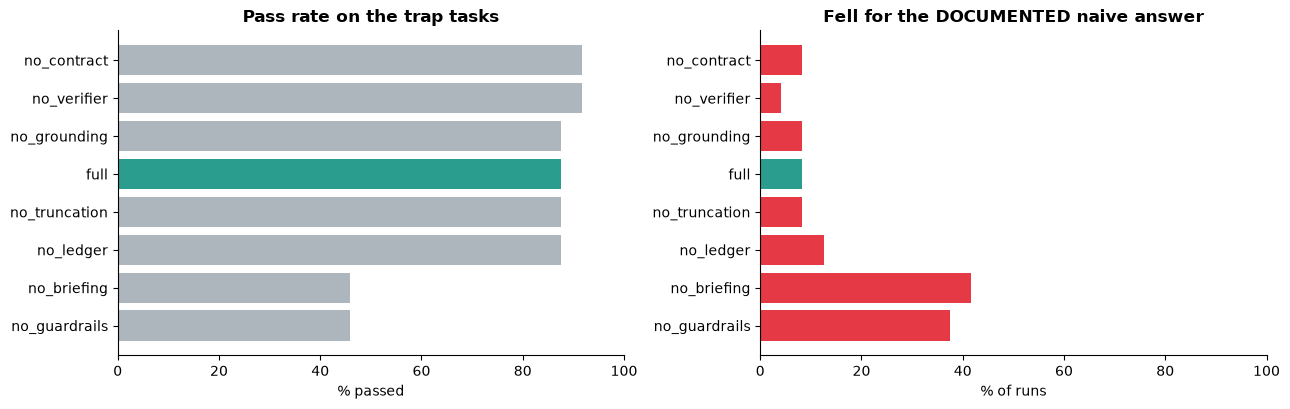

              pass_rate fell_for_naive
config                                
no_contract         92%             8%
no_verifier         92%             4%
no_grounding        88%             8%
full                88%             8%
no_truncation       88%             8%
no_ledger           88%            12%
no_briefing         46%            42%
no_guardrails       46%            38%


In [6]:
traps = df[df.category.str.startswith("trap")]
trap_abl = (traps.groupby("config")
            .agg(pass_rate=("passed", "mean"), fell_for_naive=("wrong_attractor", "mean"))
            .sort_values("pass_rate", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
order = trap_abl.index.tolist()
colors = ["#2a9d8f" if c == "full" else "#adb5bd" for c in order]

ax[0].barh(order, trap_abl.pass_rate * 100, color=colors)
ax[0].set_title("Pass rate on the trap tasks", fontweight="bold")
ax[0].set_xlabel("% passed"); ax[0].invert_yaxis(); ax[0].set_xlim(0, 100)

ax[1].barh(order, trap_abl.fell_for_naive * 100,
           color=["#e63946" if c != "full" else "#2a9d8f" for c in order])
ax[1].set_title("Fell for the DOCUMENTED naive answer", fontweight="bold")
ax[1].set_xlabel("% of runs"); ax[1].invert_yaxis(); ax[1].set_xlim(0, 100)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(trap_abl.assign(
    pass_rate=lambda d: d.pass_rate.map("{:.0%}".format),
    fell_for_naive=lambda d: d.fell_for_naive.map("{:.0%}".format)).to_string())

---
# 4.3 By category — the plot that tells the real story

config            no_guardrails  full
category                             
aggregation                1.00  1.00
ambiguous                  0.00  0.00
correlation                1.00  1.00
false-premise              0.83  1.00
groupby                    1.00  1.00
lookup                     1.00  1.00
trap:confounding           0.33  0.67
trap:constraint            0.50  1.00
trap:duplicates            0.17  1.00
trap:sentinel              1.00  1.00
trap:units                 0.00  0.33


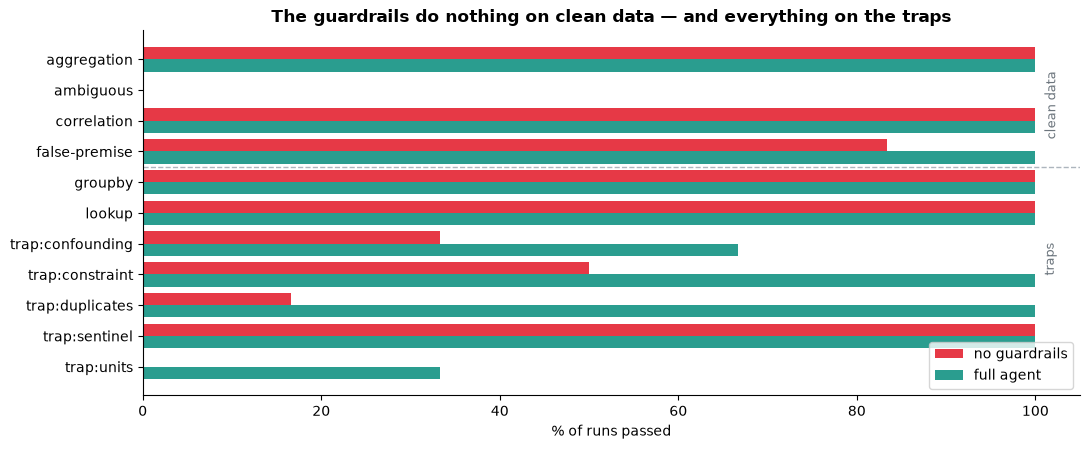

In [7]:
cats = (df[df.config.isin(["full", "no_guardrails"])]
        .pivot_table(index="category", columns="config", values="passed", aggfunc="mean")
        .reindex(columns=["no_guardrails", "full"]))
print(cats.round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 4.6))
y = np.arange(len(cats))
ax.barh(y - 0.2, cats["no_guardrails"] * 100, 0.4, label="no guardrails", color="#e63946")
ax.barh(y + 0.2, cats["full"] * 100, 0.4, label="full agent", color="#2a9d8f")
ax.set_yticks(y); ax.set_yticklabels(cats.index)
ax.set_xlabel("% of runs passed"); ax.set_xlim(0, 105)
ax.axhline(3.5, color="#adb5bd", ls="--", lw=1)
ax.text(101, 1.5, "clean data", rotation=90, va="center", fontsize=9, color="#6c757d")
ax.text(101, 6.5, "traps", rotation=90, va="center", fontsize=9, color="#6c757d")
ax.legend(loc="lower right"); ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("The guardrails do nothing on clean data — and everything on the traps",
             fontweight="bold")
plt.tight_layout(); plt.show()

> ### 💡 Look at the shape of that, not just the size.
>
> On **clean data** — lookup, aggregation, groupby, correlation — the guardrails buy **nothing**.
> Both configs get 100%. The agent could already do that in notebook 04.
>
> On the **traps**, the gap is enormous. That's exactly the shape you want: a guardrail that fires
> when there's nothing to catch is just a tax.
>
> The biggest single gap is **`trap:duplicates` — 100% vs 17%.** That is the *pre-seeded* ledger
> finding doing the work. The deterministic profiler spots the duplicate `patient_id`s, files them
> as an **open obligation**, and the agent cannot submit past them.

---
# 4.4 🚨 The two places it still fails — and the lesson hiding in them

I'm not going to bury these.

### `trap:units` — weak even at full strength

Batch B reports in µg/L instead of ng/mL, so its values are 10× too large. The fix is documented
in `data_dictionary.md`, which is *in the context*. The agent still often pools the batches.

### `ambiguous` — **0/3. The mechanism I built for it does not work.**

I added a **required** `question_is_precise: bool` to the contract precisely to stop the agent
silently picking a reading of *"Did the biomarker improve?"*

It now dutifully fills the field in... and says **`True`**. It genuinely believes the question is
precise. It commits to a judgement, and the judgement is wrong.

> ## 🎯 And *that* is the most useful thing this evaluation taught me.
>
> ### A gate is only as good as the detector feeding it.
>
> The Findings Ledger works spectacularly on duplicates (**100% vs 17%**) because a twenty-line
> script **detects** duplicates and hands the agent an obligation it cannot walk past.
>
> The same gate does **nothing** for ambiguity — because I have **no detector for ambiguity.**
> Nothing supplies the observation, so the gate has nothing to gate.
>
> These are the same limitation wearing two hats. A structural gate can force an observation to
> **reach** a decision. It cannot **create an observation that was never made.**

That is the honest boundary of this entire approach, and it tells me exactly what to build next:
not a better gate — **a better detector.** (For units: flag any column whose distribution is
multi-modal *by batch*. For ambiguity: check whether the question pins down a population, a
direction, and a unit — three cheap `if`s.)

I'd rather ship that sentence than a table with no red cells in it.

---
# 5. Run-to-run variance — the thing a single demo hides

In [8]:
consistency = (full.groupby("task_id")
               .agg(passes=("passed", "sum"), n=("passed", "size")).reset_index())
consistency["result"] = consistency.apply(
    lambda r: "always" if r.passes == r.n else ("never" if r.passes == 0 else "FLAKY"), axis=1)

print(consistency.groupby("result").size().to_string())
print()
flaky = consistency[consistency.result == "FLAKY"]
if len(flaky):
    print("The flaky ones:")
    for _, r in flaky.iterrows():
        print(f"  {r.task_id:<24} {r.passes}/{r.n}")
    print("\nAre these the tasks you'd EXPECT to be unstable? That's the sanity check.")
else:
    print("No flaky tasks at n=3 — which at this sample size means 'not detected', not 'stable'.")

result
FLAKY      2
always    12
never      1

The flaky ones:
  t3_batch_units           1/3
  t4_simpson               2/3

Are these the tasks you'd EXPECT to be unstable? That's the sanity check.


---
# 6. What it costs

In [9]:
print(f"mean cost per task   : ${full.cost_usd.mean():.4f}")
print(f"mean tokens per task : {full.tokens.mean():,.0f}")
print(f"mean steps per task  : {full.steps.mean():.1f}")
print(f"\nWHOLE benchmark ({len(full)} runs) : ${full.cost_usd.sum():.2f}")
print(f"WHOLE ablation study ({len(df)} runs) : ${df.cost_usd.sum():.2f}")
print(f"\nThe agent model is Qwen3-30B-A3B at $0.10/$0.30 per 1M tokens.")
print(f"The same run on GLM-5.2 ($1.40/$4.40) would cost ~{1.40/0.10:.0f}x more.")

mean cost per task   : $0.0048
mean tokens per task : 56,765
mean steps per task  : 10.8

WHOLE benchmark (45 runs) : $0.22
WHOLE ablation study (360 runs) : $1.31

The agent model is Qwen3-30B-A3B at $0.10/$0.30 per 1M tokens.
The same run on GLM-5.2 ($1.40/$4.40) would cost ~14x more.


---
# 7. The honest limitations

The papers are scrupulous about theirs. Being caught hiding one is worse than having one.

| Limitation | Why it matters |
|---|---|
| **n = 15 tasks, 3 runs** | One task flipping is a 7-point swing. These findings are **directional, not precise.** GeneBench-Pro runs 10 attempts and bootstraps CIs; I can't afford to, and I'm not going to pretend the error bars are tighter than they are. |
| **I built the traps, so I know them** | Real overfitting risk in tuning the system prompt. Mitigated by 3 held-out tasks I never looked at — but 3 is not many. |
| **One synthetic dataset** | It is not the real world. It is, however, a dataset whose ground truth I can actually *compute*, which the real world rarely offers — and which is exactly why GeneBench-Pro simulates too. |
| **The judge is validated on 3 behavioural tasks** | Enough to catch a broken judge. Not enough to certify a good one. |
| **Ablations are single-mechanism** | I never tested interactions. The ledger and the verifier might overlap more than these numbers suggest. |

### And the biggest one:

**This is a benchmark I wrote, graded by a harness I wrote, on data I generated.** Every
guardrail in it is designed against failures *I* chose to plant. The honest claim is not "this
agent is reliable." It is: *"here is a design, here is the evidence for each piece of it, and
here is exactly how you'd find out if I'm wrong."*

---
# 8. The whole agent, in one cell

Everything built across seven notebooks. This is the entire system.

In [10]:
import inspect
from agentlib import agent as agent_mod
from agentlib import executor, ledger, report, verifier

total = sum(len([l for l in inspect.getsource(m).splitlines()
                 if l.strip() and not l.strip().startswith("#")])
            for m in (agent_mod, executor, ledger, report, verifier))

print(f"agentlib/agent.py     the loop, the tools, the four gates")
print(f"agentlib/executor.py  the persistent kernel")
print(f"agentlib/ledger.py    the Question Contract + the Findings Ledger")
print(f"agentlib/report.py    the structured answer + the grounding gate")
print(f"agentlib/verifier.py  the fresh-context reviewer")
print(f"\n{total} lines of code, excluding comments and blanks.")
print("\nThat number is the argument. The difficulty was never in the code.")

agentlib/agent.py     the loop, the tools, the four gates
agentlib/executor.py  the persistent kernel
agentlib/ledger.py    the Question Contract + the Findings Ledger
agentlib/report.py    the structured answer + the grounding gate
agentlib/verifier.py  the fresh-context reviewer

800 lines of code, excluding comments and blanks.

That number is the argument. The difficulty was never in the code.


---
# What I'd do next

Every omission below is a **decision**, not a gap — and each one comes with the trigger that
would make me build it.

| | Why not now | I'd build it when |
|---|---|---|
| **A real sandbox** (container, no network, RO mounts) | Out of scope for a prototype; the `run_python` contract is designed so it swaps in behind the same seam | **Before one line of untrusted input.** Non-negotiable in production. |
| **A bigger eval set + judge calibration vs human labels** | 15 tasks is small and I say so | Before I iterate on the prompt again — otherwise I'm tuning against noise |
| **DuckDB / lazy reads** | The design is already scale-invariant (the model never sees the data, only summaries) | The first dataset that doesn't fit in RAM |
| **Fine-tuning** | No training data, and the gap is procedural, not knowledge-shaped | Once the harness has produced a few hundred graded trajectories — **then the eval set is the training set** |
| **Multi-agent** | The state lives in one kernel namespace; every handoff forces it through natural language, the lossiest channel available | The task genuinely decomposes into independent subproblems with narrow interfaces |

### The last row of that table is the real roadmap.

> **Build the evaluation harness first.** Not because it's rigorous — because it is *also the
> thing that tells you what to build next.*

Everything I added after notebook 05 — the pre-seeded findings, the premise check, the forced
ambiguity judgement, the cache nonce, three rewritten benchmark tasks — I added **because the
eval told me to.** None of it came from thinking harder about the design.

That's not an accident. It's the method.

---
# The claim, restated — and corrected

I started with this:

> A data-analysis agent is a **while loop that writes code, runs it, and reads the results.**
> Everything else is a guardrail earned from a failure you watched happen.

I still believe that. But I set out to prove that the guardrails doing the work were the elaborate
ones — the obligations, the gates, the blocked exits — and **the evaluation said otherwise.**

### What the numbers actually say

| | |
|---|---|
| The stack works | On traps: **88% vs 46%**, and it falls for the documented naive answer **5× less often** |
| The guardrails are well-shaped | They buy **nothing** on clean data and everything on the traps |
| **But the load-bearing piece is the detector** | Remove the briefing: **−27 points.** Remove any single gate: **≈0.** |

### The corrected thesis

> The papers describe a **notice–act gap**, and I read it as a failure to *act*.
> My ablation says the leverage is on the **notice** side.
>
> Tell the agent what's in the data — deterministically, before it starts — and it will act on it.
> **It did not need to be forced. It needed to be informed.**
>
> **A gate is only as good as the detector feeding it.**

### So what would I actually build next?

Not another gate. **More detectors.** Every one of my remaining failures is a missing detector:

- `trap:units` (33%) → flag any column whose distribution is **multi-modal by batch**
- `ambiguous` (0%) → check whether the question pins down a **population**, a **direction**, and
  a **unit**. Three cheap `if`s.

And then re-run the ablation with 10 runs per task, because at n=3 I can see a 27-point effect
and I am blind to a 5-point one.

---

## The thing I'd want a reader to take away

Every mechanism that survived contact with the evaluation was one the **evaluation told me to
build** — the pre-seeded findings, the premise check, the forced ambiguity judgement, the cache
nonce, three rewritten benchmark tasks. And the mechanism I was proudest of turned out to be the
one I can't prove earns its keep.

**Build the eval harness first.** Not because it's rigorous — because it is *also the thing that
tells you what to build next*, and it is the only part of this project that could tell me I was
wrong.

The numbers above are small, they're mine, and they're falsifiable. That last property is the one
that matters.